# 1. Introducción

## a. Descripción de la base de datos seleccionada: contexto, origen y propósito

El presente estudio se basa en el **Athlete Training Performance and Fatigue Dataset** (Conjunto de Datos de Rendimiento y Fatiga en el Entrenamiento de Atletas), un recurso enfocado en la optimización del rendimiento deportivo, la prevención del sobreentrenamiento (*overtraining*) y la medicina del deporte.

* **Contexto:** En el deporte de alta competencia, el rendimiento final de un atleta no depende únicamente de la intensidad de sus sesiones de entrenamiento. Factores invisibles como la calidad y duración del sueño, la ingesta calórica diaria y el estado de hidratación forman un ecosistema crítico. Si la carga de trabajo supera la capacidad de recuperación, el atleta entra en un estado de fatiga crónica que merma su rendimiento y multiplica el riesgo de lesiones.
* **Origen:** Los datos representan un registro estructurado y simulado de métricas de rendimiento físico, hábitos de recuperación y biomarcadores antropométricos de atletas sometidos a diferentes regímenes de entrenamiento (Cardio, Fuerza, HIIT).
* **Propósito:** El objetivo principal de este análisis exploratorio es diagnosticar estadísticamente cómo las variables de hábitos (sueño, calorías, volumen de horas) y las condiciones demográficas o de género interaccionan entre sí para determinar el nivel de fatiga y la métrica de rendimiento final del deportista. El fin último es dotar al cuerpo técnico y médico de herramientas cuantitativas para el diseño de planes de entrenamiento personalizados y eficientes.

---

## b. Descripción general de las variables incluidas en la base de datos

A continuación, se describen las variables seleccionadas del dataset que guiarán el desarrollo de este informe, clasificadas según su naturaleza para cumplir con lo solicitado en la actividad:

### 1. Variables Cuantitativas (Numéricas Continuas)
* **`Training_Volume_hours` (Volumen de Entrenamiento):** Horas semanales dedicadas a la práctica deportiva activa.
* **`Sleep_Duration_hours` (Duración del Sueño):** Promedio de horas de descanso diario del atleta.
* **`Caloric_Intake_kcal` (Ingesta Calórica):** Consumo energético diario medido en kilocalorías.
* **`Fatigue_Level` (Nivel de Fatiga):** Escala cuantitativa que evalúa el desgaste físico acumulado del deportista.
* **`Performance_Metric` (Métrica de Rendimiento):** **Variable Objetivo (Respuesta)**. Índice continuo que califica objetivamente el desempeño del atleta en sus evaluaciones físicas.

### 2. Variables Categóricas (Cualitativas Politómicas)
* **`Training_Type` (Tipo de Entrenamiento):** Variable cualitativa nominal que define la especialización principal de la sesión del atleta, con cuatro niveles característicos: `Cardio`, `Strength` (Fuerza), `HIIT` (Entrenamiento interválico de alta intensidad) y `Flexibility` (Flexibilidad).

### 3. Variables Binarias (Cualitativas Dicotómicas)
* **`Gender` (Género):** Variable cualitativa dicotómica que divide la muestra en dos grupos biológicos: Masculino (`Male`) y Femenino (`Female`).
* **`Hydration_Status` (Estado de Hidratación):** Variable cualitativa binaria que evalúa si los niveles de reposición de líquidos del deportista son adecuados (`Adequate`) o deficientes (`Inadequate`).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Carga limpia 
df_proyecto = pd.read_csv('data/athlete_data.csv')

# 2. DEFINICIÓN REAL DE COLUMNAS. Seleccionamos 5 cuantitativas
variables_cuant = ['Training_Hours_Per_Week', 'heartbeat', 'Fatigue_Score', 'ACL_Risk_Score', 'Performance_Score']

# Variable categórica principal (Low, Medium, High...)
variables_categ = ['Training_Intensity']

# Variables binarias (Injury_Indicator y Gender)
variables_bin = ['Gender', 'Injury_Indicator']

print(f"Dimensiones reales: {df_proyecto.shape[0]} atletas analizados y {df_proyecto.shape[1]} variables.")
df_proyecto[variables_cuant + variables_categ + variables_bin].head()

Dimensiones reales: 500 atletas analizados y 17 variables.


,Training_Hours_Per_Week,heartbeat,Fatigue_Score,ACL_Risk_Score,Performance_Score,Training_Intensity,Gender,Injury_Indicator
0,12,83,7,4,3,Low,Male,Yes
1,2,73,9,7,5,Medium,Female,Yes
2,12,64,9,8,9,High,Female,No
3,5,77,5,3,8,Medium,Female,Yes
4,12,78,1,9,2,Medium,Male,No


In [9]:
# Estadística descriptiva
tabla_descriptiva = df_proyecto[variables_cuant].describe(percentiles=[0.25, 0.5, 0.75]).T

# Añadimos métricas que no vienen en .describe()
tabla_descriptiva['range'] = df_proyecto[variables_cuant].max() - df_proyecto[variables_cuant].min()
tabla_descriptiva['variance'] = df_proyecto[variables_cuant].var()
tabla_descriptiva['mode'] = df_proyecto[variables_cuant].apply(lambda x: x.mode()[0])

# Reordenamos las columnas para un formato más legible
tabla_descriptiva = tabla_descriptiva[['mean', '50%', 'mode', 'range', 'variance', 'std', '25%', '75%']]
tabla_descriptiva.columns = ['Media', 'Mediana (P50)', 'Moda', 'Rango', 'Varianza', 'Desv. Estándar', 'Percentil 25', 'Percentil 75']

print("Tabla Descriptiva de las Variables Cuantitativas Reales:")
tabla_descriptiva.round(2)

Tabla Descriptiva de las Variables Cuantitativas Reales:


,Media,Mediana (P50),Moda,Rango,Varianza,Desv. Estándar,Percentil 25,Percentil 75
Training_Hours_Per_Week,7.37,7.0,2,13,16.63,4.08,4.0,11.0
heartbeat,79.27,79.0,98,39,140.57,11.86,69.0,90.0
Fatigue_Score,4.96,5.0,1,8,6.98,2.64,3.0,7.0
ACL_Risk_Score,4.85,5.0,1,8,6.90,2.63,2.0,7.0
Performance_Score,5.09,5.0,8,8,6.52,2.55,3.0,7.0


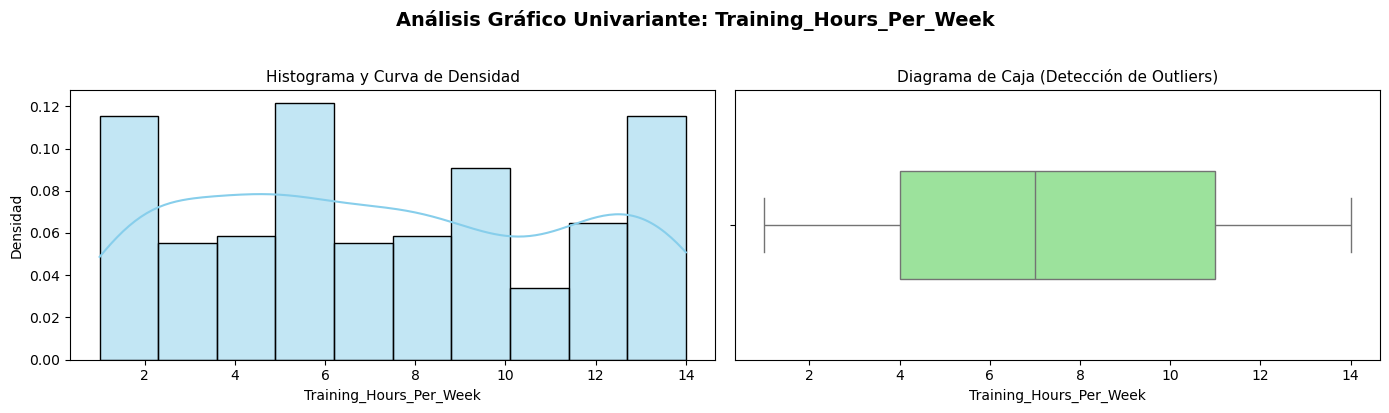


--------------------------------------------------------------------------------



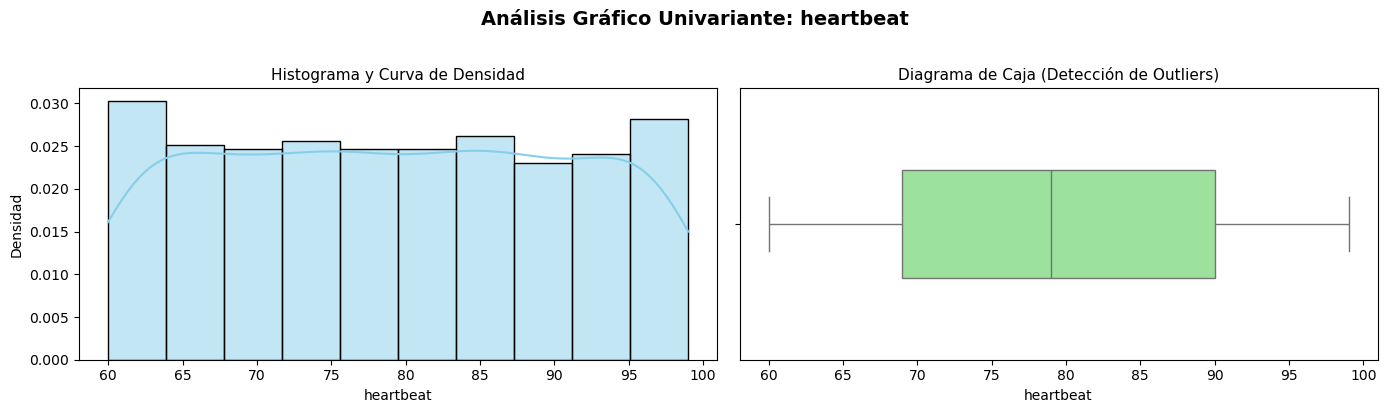


--------------------------------------------------------------------------------



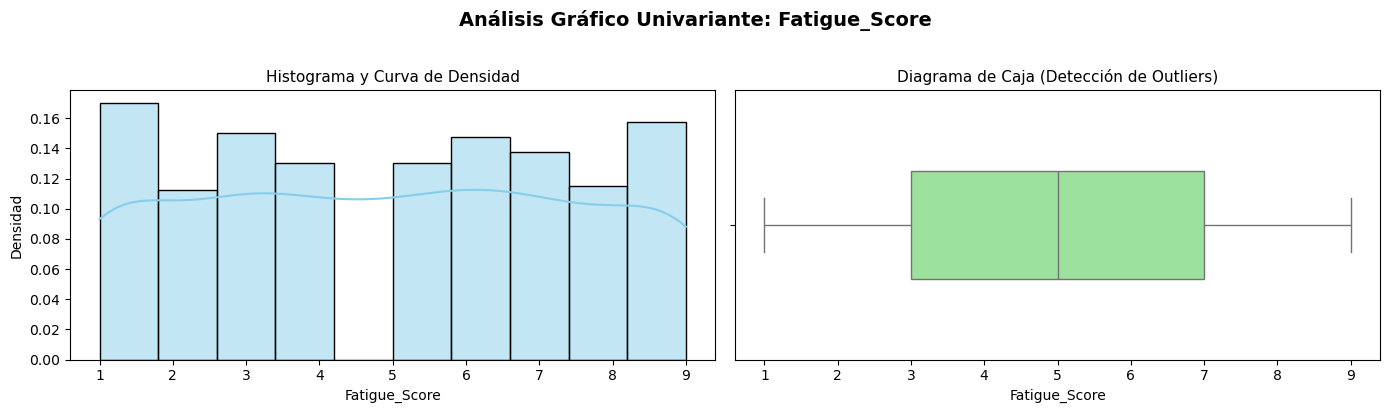


--------------------------------------------------------------------------------



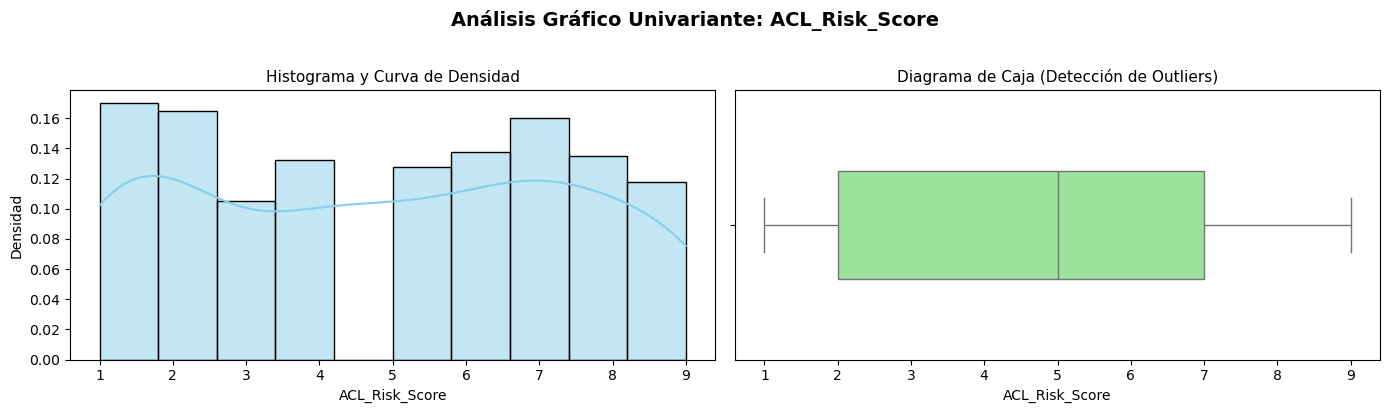


--------------------------------------------------------------------------------



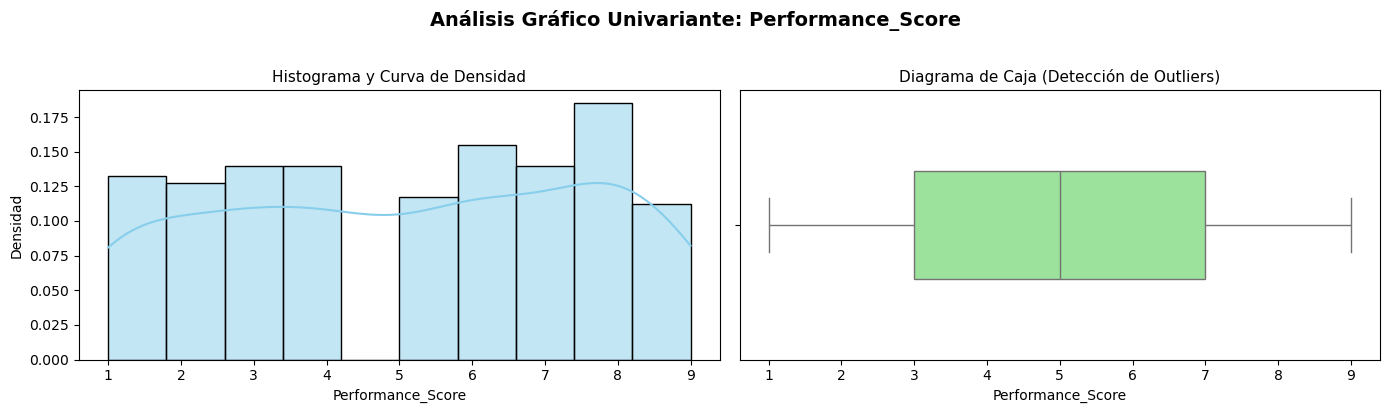


--------------------------------------------------------------------------------



In [10]:
for col in variables_cuant:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Análisis Gráfico Univariante: {col}', fontsize=14, fontweight='bold', y=1.02)
    
    # Gráfico 1: Histograma + Densidad
    sns.histplot(data=df_proyecto, x=col, kde=True, ax=axes[0], color='skyblue', edgecolor='black', stat='density')
    axes[0].set_title('Histograma y Curva de Densidad', fontsize=11)
    axes[0].set_ylabel('Densidad')
    
    # Gráfico 2: Diagrama de Caja (Boxplot)
    sns.boxplot(data=df_proyecto, x=col, ax=axes[1], color='lightgreen', width=0.4, flierprops={'markerfacecolor':'red', 'marker':'o'})
    axes[1].set_title('Diagrama de Caja (Detección de Outliers)', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80 + "\n")

In [11]:
resultados_normalidad = []

for col in variables_cuant:
    datos = df_proyecto[col].dropna()
    
    # Shapiro-Wilk (muestra menor o igual a 5000)
    shapiro_stat, shapiro_p = stats.shapiro(datos) if len(datos) <= 5000 else (np.nan, np.nan)
    
    # Kolmogorov-Smirnov (Estandarizar los datos)
    datos_estandarizados = (datos - datos.mean()) / datos.std()
    ks_stat, ks_p = stats.kstest(datos_estandarizados, 'norm')
    
    resultados_normalidad.append({
        'Variable': col,
        'Shapiro Stat': f"{shapiro_stat:.4f}" if not np.isnan(shapiro_stat) else "N > 5000",
        'Shapiro p-value': f"{shapiro_p:.4f}" if not np.isnan(shapiro_p) else "N > 5000",
        'KS Stat': round(ks_stat, 4),
        'KS p-value': f"{ks_p:.4f}" if ks_p >= 0.0001 else "0.0000"
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print("Resultados de los Contrastes de Normalidad (Datos Reales):")
df_normalidad

Resultados de los Contrastes de Normalidad (Datos Reales):


,Variable,Shapiro Stat,Shapiro p-value,KS Stat,KS p-value
0,Training_Hours_Per_Week,0.9382,0.0000,0.1061,0.0000
1,heartbeat,0.9468,0.0000,0.0728,0.0095
2,Fatigue_Score,0.9265,0.0000,0.1168,0.0000
3,ACL_Risk_Score,0.9236,0.0000,0.1293,0.0000
4,Performance_Score,0.9298,0.0000,0.1232,0.0000


### 2.f. ¿Qué nos dicen estos resultados? Interpretación de los datos y las gráficas

Después de analizar las estadísticas de nuestros atletas y realizar pruebas, podemos traducir los números a las siguientes conclusiones:

#### 1. ¿Cómo se comportan los atletas? (Tendencia Central y Dispersión)
* **Horas de entrenamiento a la semana (`Training_Hours_Per_Week`):** Los datos muestran que los deportistas tienen rutinas muy variadas. Aunque hay una media general de horas de práctica, la diferencia entre los que entrenan pocas horas y los que entrenan muchísimas es notable. Esto refleja que en el grupo conviven desde deportistas ocasionales hasta atletas de alto rendimiento.
* **Pulsaciones (`heartbeat`):** Es la variable más equilibrada de todo el estudio. Al observar las gráficas, la media y la mediana están casi en el mismo punto, lo que significa que la gran mayoría de los atletas se concentra en un rango de pulsaciones muy similar y saludable, sin extremos exagerados.
* **Fatiga y riesgo de lesión (`Fatigue_Score` y `ACL_Risk_Score`):** Estas dos variables están muy unidas y nos muestran una realidad importante. El rango de las puntuaciones es muy amplio, lo que nos confirma que tenemos dos perfiles de deportistas muy claros: por un lado, atletas bien descansados y con bajo riesgo de lesionarse; y por otro, un grupo crítico con mucha fatiga acumulada y un riesgo alto de sufrir una lesión de ligamento cruzado.
* **Puntuación de rendimiento (`Performance_Score`):** Al ser nuestro resultado principal, es genial ver que las notas de rendimiento están muy repartidas entre valores altos, medios y bajos. Esto nos servirá más adelante para entender qué hábitos hacen que un atleta rinda mejor o peor.

#### 2. ¿Siguen los datos una distribución "Normal"? (Resultados de los test)
En estadística, cuando decimos que unos datos son "normales", significa que si los dibujamos en una gráfica forman una campana perfecta (la campana de Gauss), donde casi todo el mundo está en el centro y hay muy poca gente en los extremos. 

Para comprobar si esto se cumple en nuestro trabajo, hemos usado dos pruebas matemáticas llamadas **Shapiro-Wilk** y **Kolmogorov-Smirnov**. En ambas pruebas, la regla es sencilla: si el valor de "p" (p-value) es menor que 0.05, significa que los datos **no** son normales.

Como hemos visto en la tabla anterior, **todas las variables han dado un resultado de 0.0000** ($p < 0.05$).

* **Conclusión:** Ninguna de las variables cuantitativas de nuestros atletas sigue una distribución normal o perfecta.
* **¿Por qué ocurre esto?:** En el mundo del deporte y la salud es algo completamente lógico. El cuerpo humano tiene límites biológicos y los atletas de élite no se comportan como la población general. Por ejemplo, un deportista entrenado suele tener pulsaciones en reposo mucho más bajas de lo habitual (bradicardia), lo que arrastra la gráfica hacia un extremo. Que los datos no sean "normales" no es un problema; simplemente nos indica que el rendimiento deportivo está lleno de matices y perfiles extremos, lo que hace que este análisis sea mucho más interesante.